In [11]:
# Load all of 155 Forestero-provided sites

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Point
from matplotlib.ticker import StrMethodFormatter, MaxNLocator
import seaborn as sns

sns.set_theme()

In [2]:
from utils.site import Site
from utils.tree import Tree
from utils.constants import GH_TREE_COORDS_FILEPATH, SILVER_FOLDERPATH, GHANA_GDF

In [3]:
df = pd.read_excel(GH_TREE_COORDS_FILEPATH)
df.head(3)

,Pays,Région,Region code,Site Nb,Site Name,Tree N.,Tree Latitude,Tree Longitude
0,Ghana,Central,CR,1,FO05,T1,5.323065,-1.173049
1,Ghana,Central,CR,2,FO06,T1,5.431284,-1.157774
2,Ghana,Central,CR,3,FO07,T1,5.538543,-1.185850


In [4]:
# 155 sites, spread across 6 regions
print("# sites:", df["Site Name"].nunique())
print("# regions:", df["Région"].nunique())
print("# site per regions:")
df.groupby("Région")["Site Name"].nunique().sort_values()

# sites: 155
# regions: 6
# site per regions:


Région
Brong-Ahafo      15
Eastern          18
Central          20
Western-South    31
Ashanti          32
Western-North    39
Name: Site Name, dtype: int64

In [5]:
# No site spread across two regions
df.groupby("Site Name")["Région"].nunique().unique()

array([1])

In [6]:
# Each site has 5 trees
print("# trees per site:")
df.groupby("Site Name")["Tree N."].count().unique()

# trees per site:


array([5])

In [7]:
# Add points
df["point"] = df.apply(axis=1, func=lambda row: Point((row["Tree Longitude"], row["Tree Latitude"])))
df.head(3)

,Pays,Région,Region code,Site Nb,Site Name,Tree N.,Tree Latitude,Tree Longitude,point
0,Ghana,Central,CR,1,FO05,T1,5.323065,-1.173049,POINT (-1.173049 5.323065)
1,Ghana,Central,CR,2,FO06,T1,5.431284,-1.157774,POINT (-1.157774 5.431284)
2,Ghana,Central,CR,3,FO07,T1,5.538543,-1.185850,POINT (-1.18585 5.538543)


In [8]:
gdf = gpd.GeoDataFrame(df, geometry="point", crs="EPSG:4326")
gdf.head(3)

,Pays,Région,Region code,Site Nb,Site Name,Tree N.,Tree Latitude,Tree Longitude,point
0,Ghana,Central,CR,1,FO05,T1,5.323065,-1.173049,POINT (-1.17305 5.32306)
1,Ghana,Central,CR,2,FO06,T1,5.431284,-1.157774,POINT (-1.15777 5.43128)
2,Ghana,Central,CR,3,FO07,T1,5.538543,-1.185850,POINT (-1.18585 5.53854)


<Axes: title={'center': '775 trees provided by Forestero, on Ghana'}, xlabel='Lon', ylabel='Lat'>

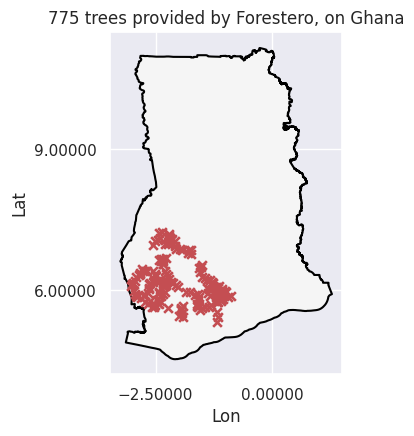

In [9]:
# Plot all sites
f = plt.figure(figsize=(3, 5))
ax = plt.gca()

# Make the lon/lat easier to read
ax.xaxis.set_major_locator(MaxNLocator(nbins=2))
ax.yaxis.set_major_locator(MaxNLocator(nbins=2))
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:.5f}"))
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:.5f}"))
plt.xlabel('Lon')
plt.ylabel('Lat')
plt.title(f"{len(gdf)} trees provided by Forestero, on Ghana")

# Plot full map
GHANA_GDF.plot(ax=ax,color="whitesmoke", edgecolor="black", linewidth=1.5)
gdf.plot(ax=ax, marker='x', c='r', alpha=0.8)

In [10]:
sites = []
for site_name, row_idxs in df.groupby("Site Name").groups.items():
    trees = []
    for _, row in df.iloc[row_idxs].iterrows():
        lon_lat = (row["Tree Longitude"], row["Tree Latitude"])
        t = Tree(point=Point(lon_lat))
        trees.append(t)

    s = Site(trees=trees, id=site_name, region=row["Région"])
    sites.append(s)

In [11]:
# All convex-hulls areas
print("# m2 of confirmed-cocoa trees:", sum(e.area_m2 for e in sites))

# m2 of confirmed-cocoa trees: 179775.05632365667


Text(0.5, 0, 'Area [m2]')

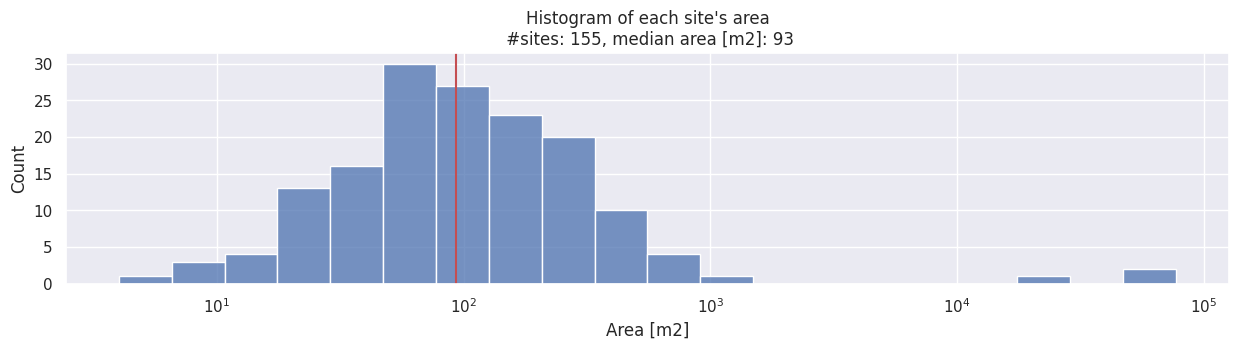

In [12]:
# Histogram of convex-hull-areas
plt.figure(figsize=(15, 3))
areas = [e.area_m2 for e in sites]
sns.histplot(areas, log_scale=True)
plt.axvline(x=np.median(areas), c="r")
plt.title(f"Histogram of each site's area\n #sites: {len(sites)}, median area [m2]: {np.median(areas):.0f}")
plt.xlabel("Area [m2]")

In [13]:
areas = [e.area_m2 for e in sites]

SB10 77036.5010677129
POINT (-2.428749 5.958954)
POINT (-2.348124 6.087798)
POINT (-2.348228 6.087788)
POINT (-2.348189 6.087812)
POINT (-2.348219 6.087785)


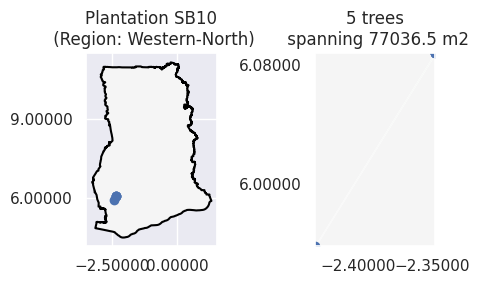

HU05 60833.272432337035
POINT (-1.950002 5.578209)
POINT (-1.934967 5.505201)
POINT (-1.935101 5.505191)
POINT (-1.935047 5.505213)
POINT (-1.935053 5.505235)


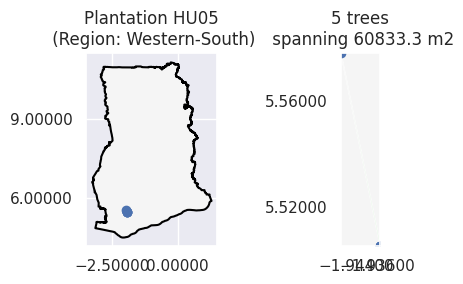

SU05 19542.307114465875
POINT (-2.144758 7.096424)
POINT (-2.144697 7.096423)
POINT (-2.144685 7.064429)
POINT (-2.144658 7.096436)
POINT (-2.144667 7.096441)


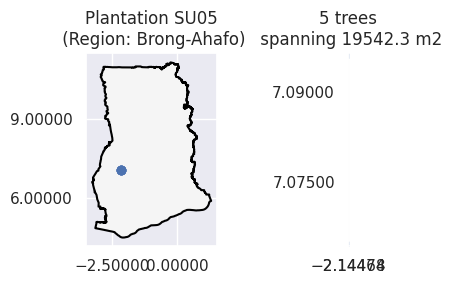

In [19]:
# Figure out which sites have outlier trees
idxs = np.argsort(areas)[::-1]
for site in np.array(sites)[idxs]:
    if site.area_m2 > 1e3:
        print(site.id, site.area_m2)
        for t in site.trees:
            print(t.point)
        site.plot()
    else:
        continue

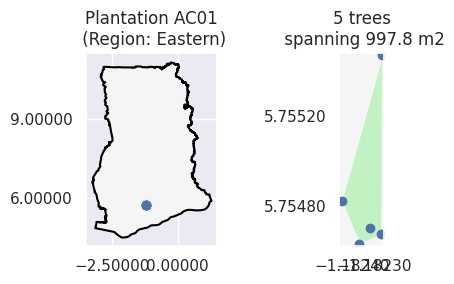

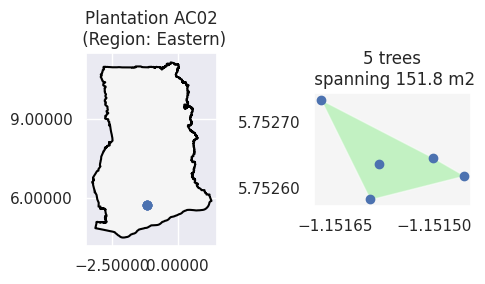

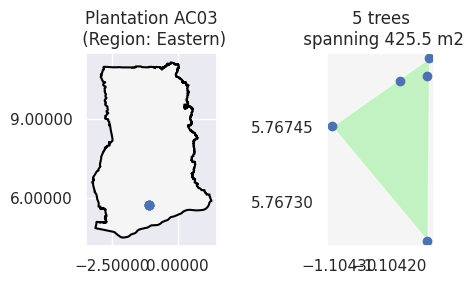

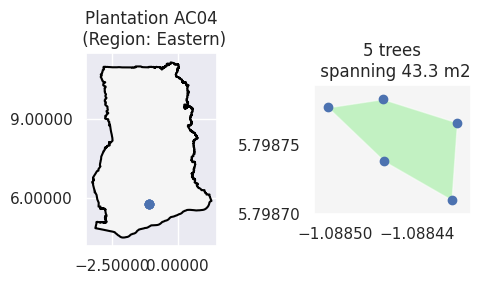

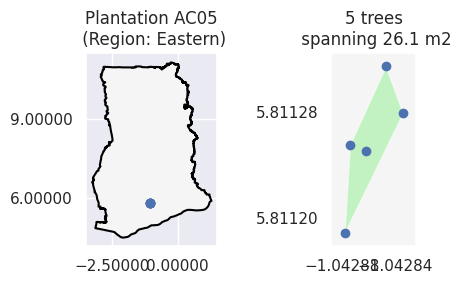

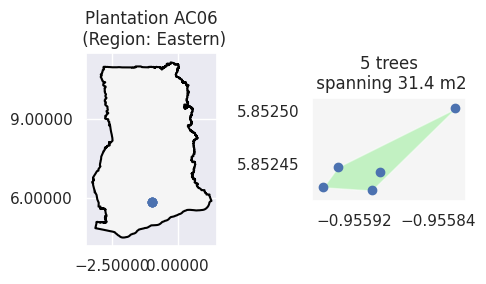

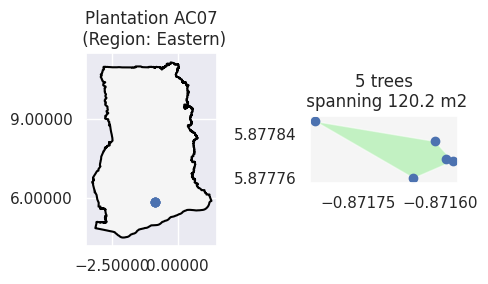

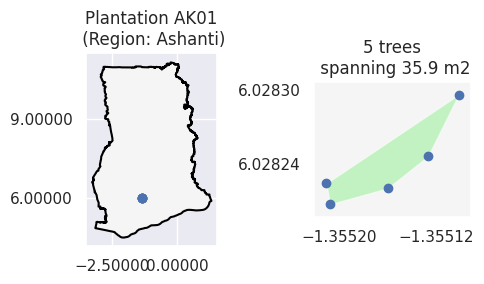

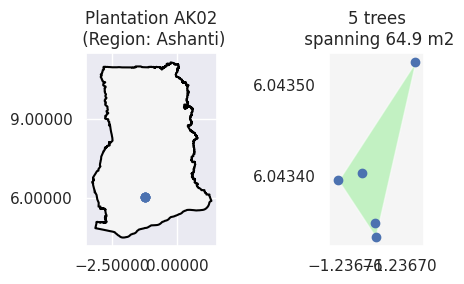

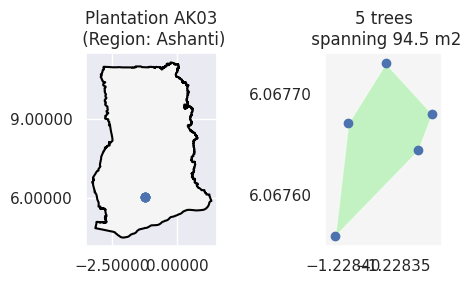

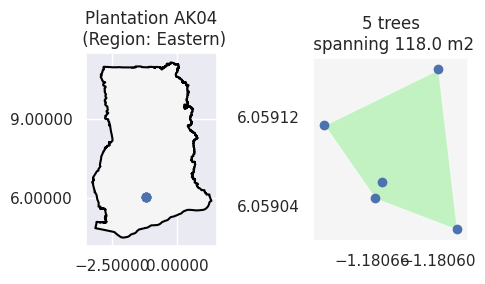

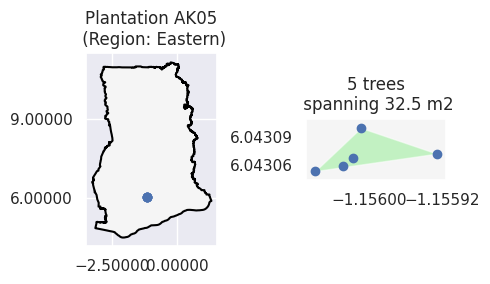

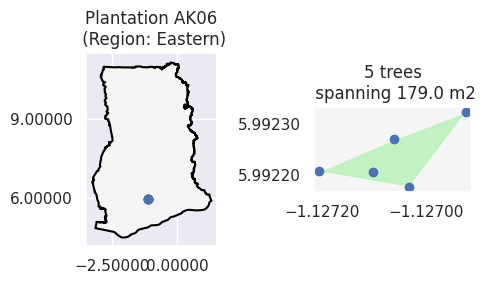

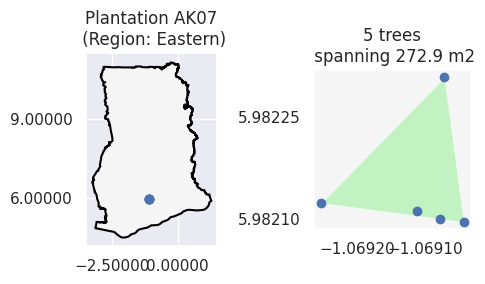

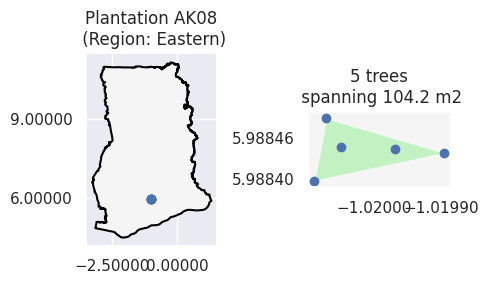

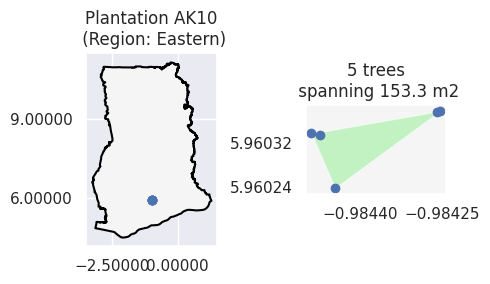

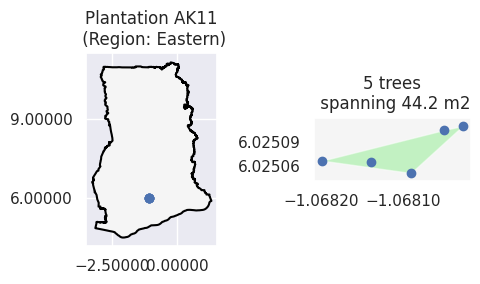

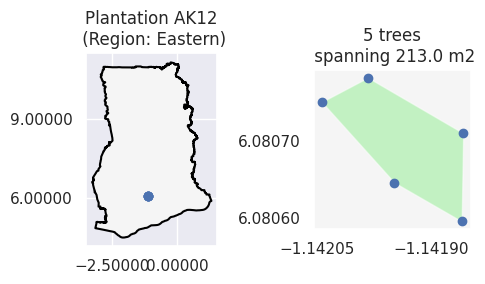

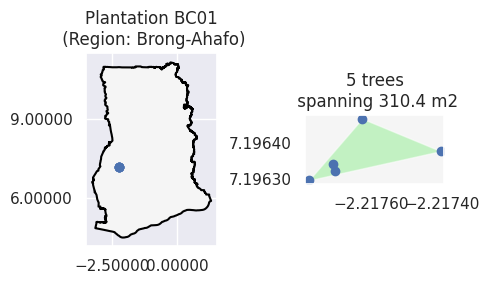

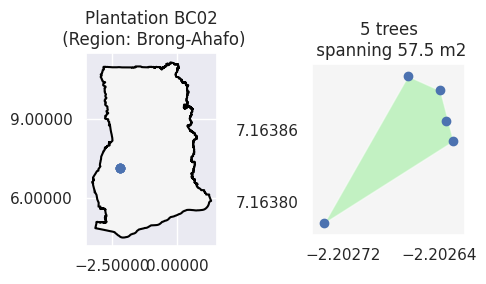

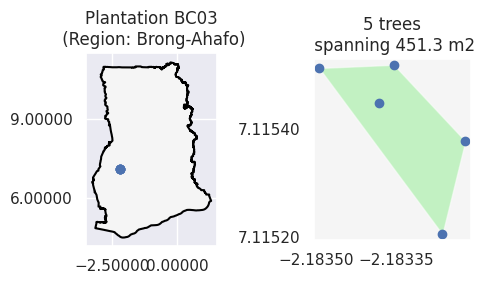

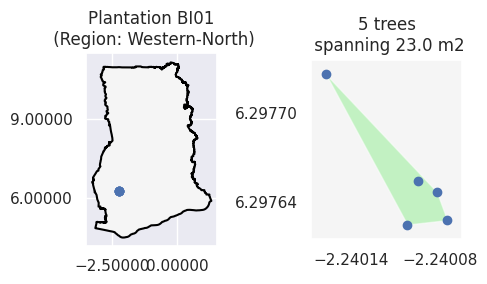

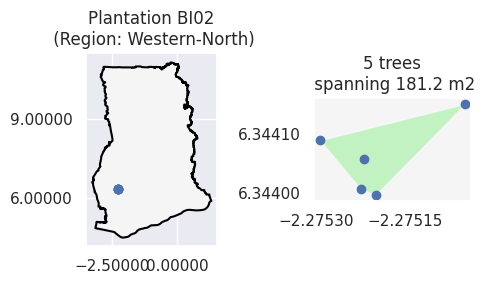

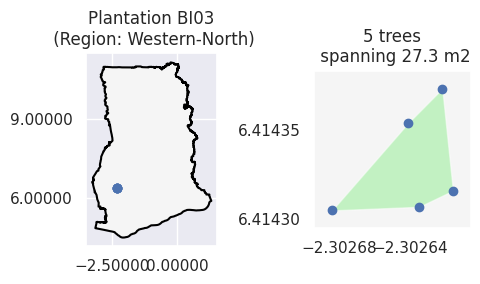

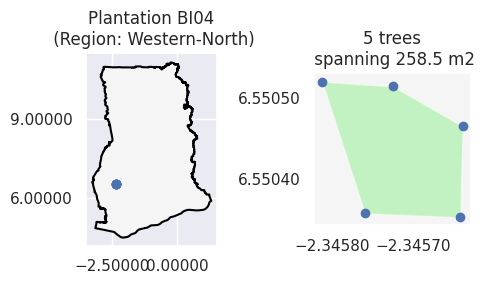

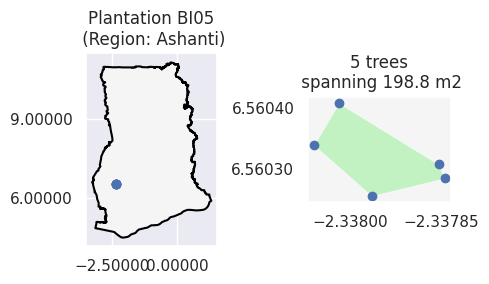

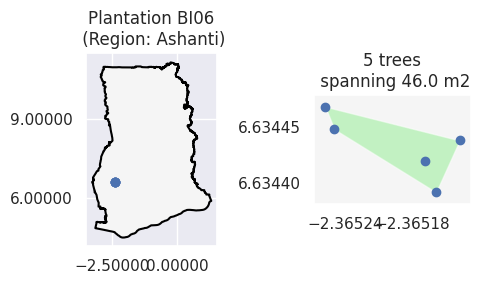

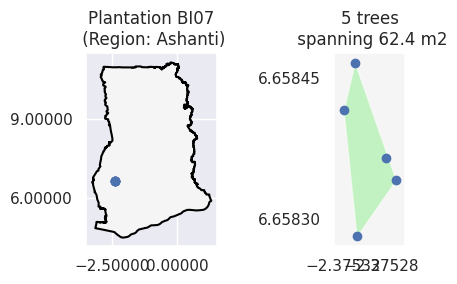

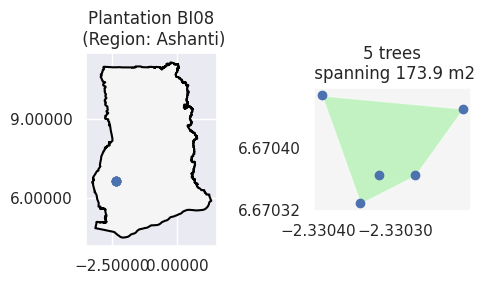

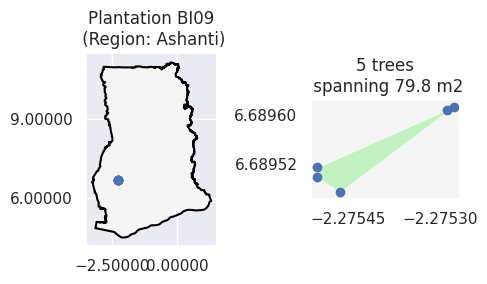

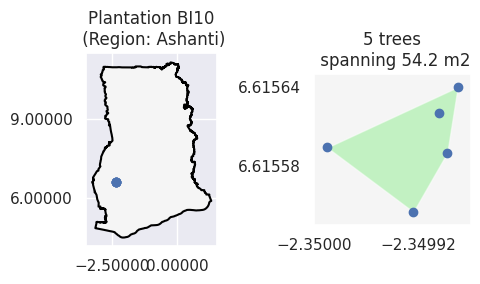

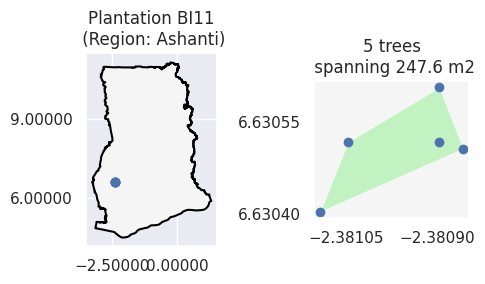

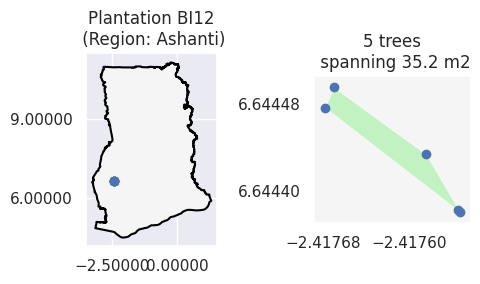

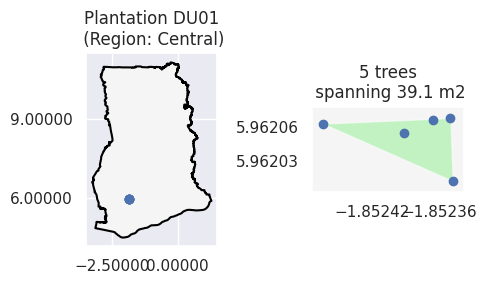

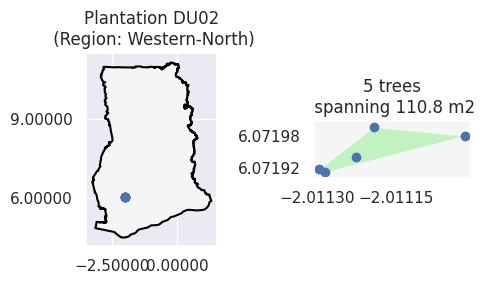

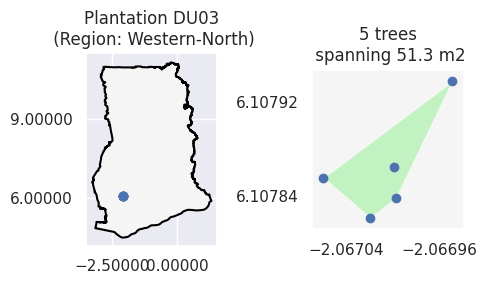

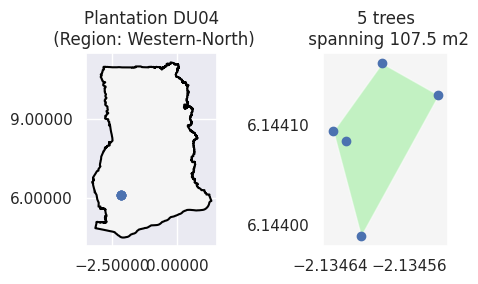

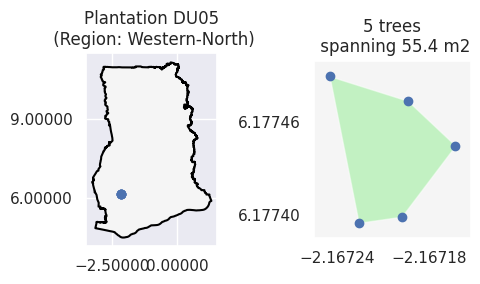

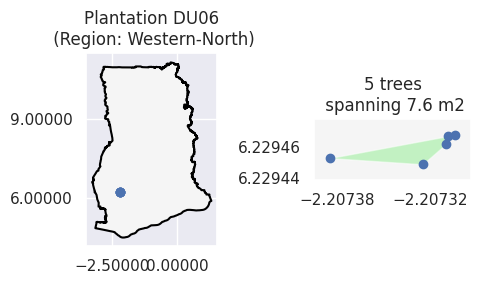

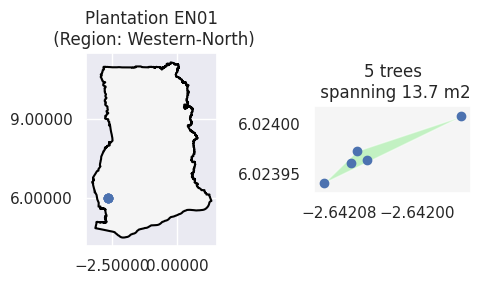

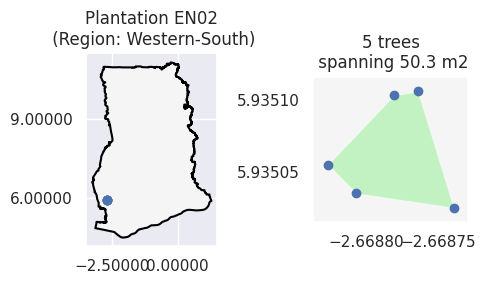

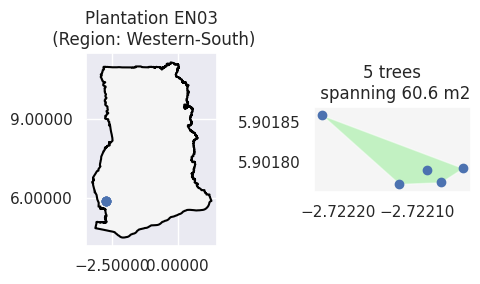

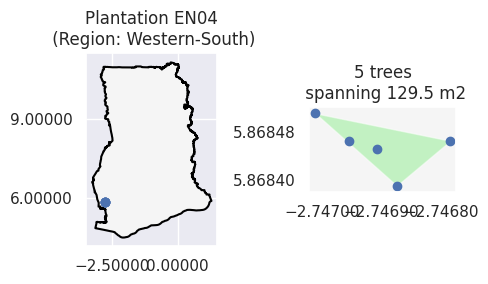

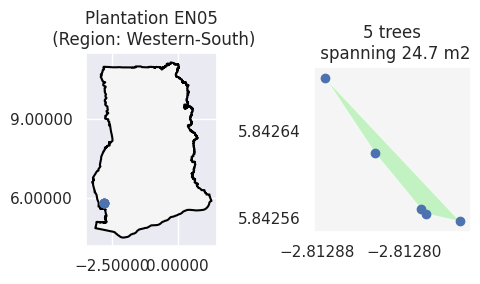

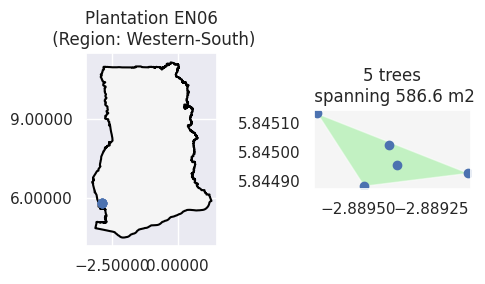

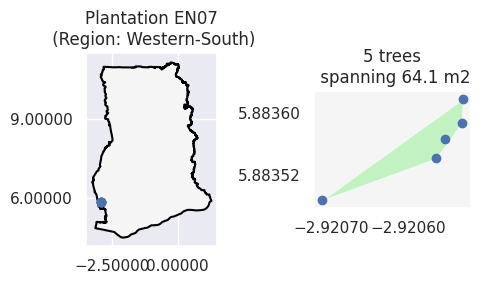

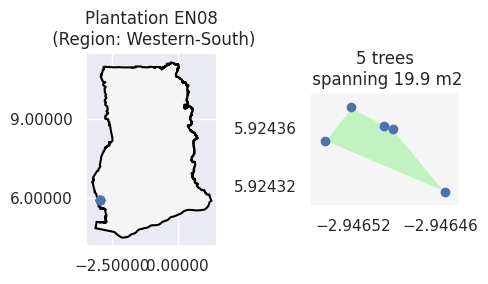

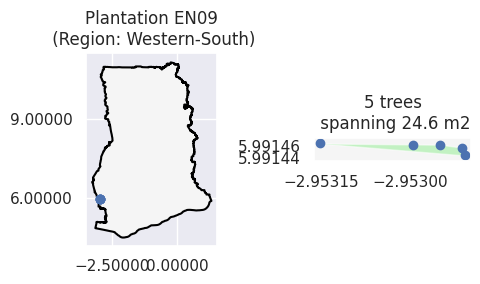

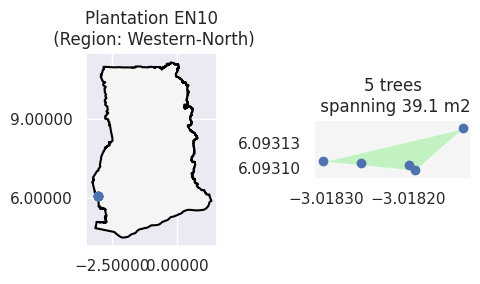

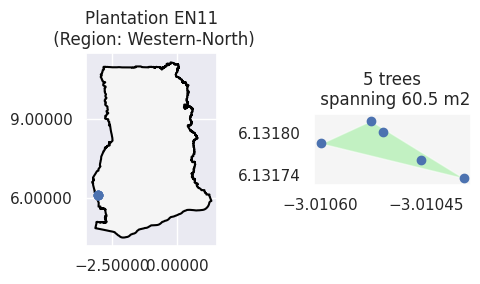

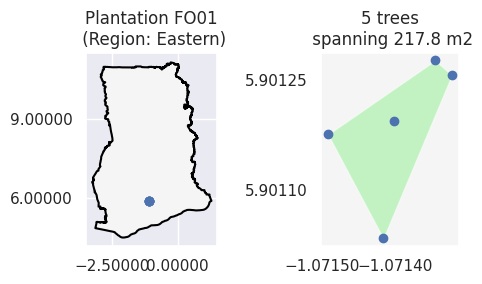

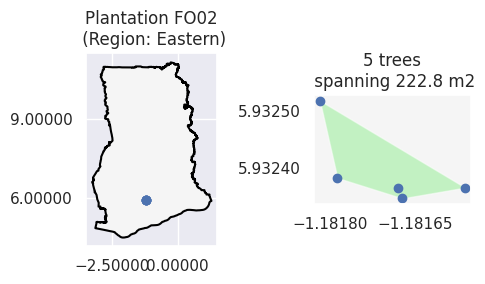

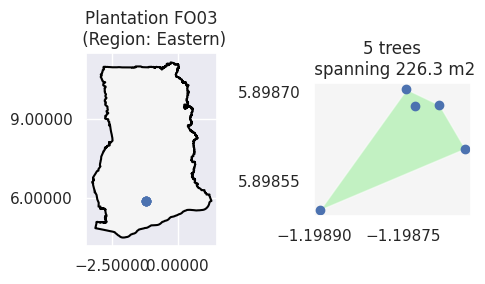

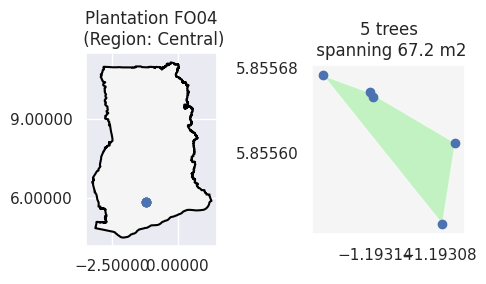

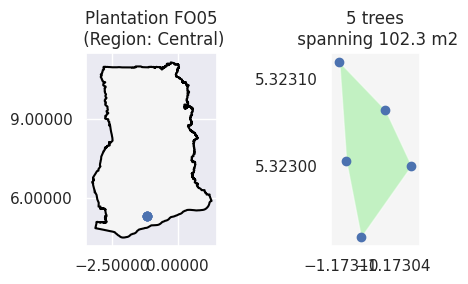

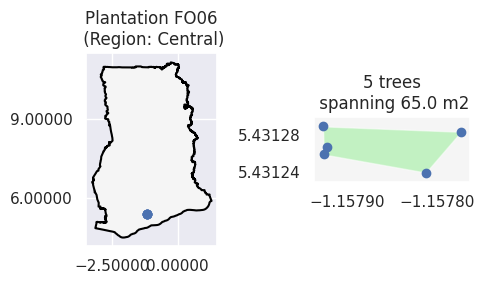

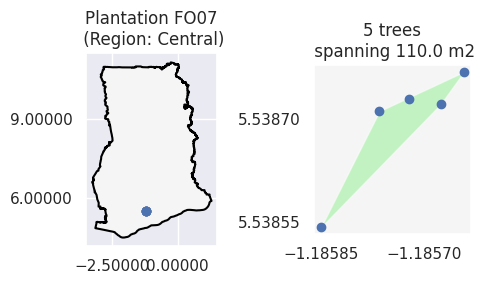

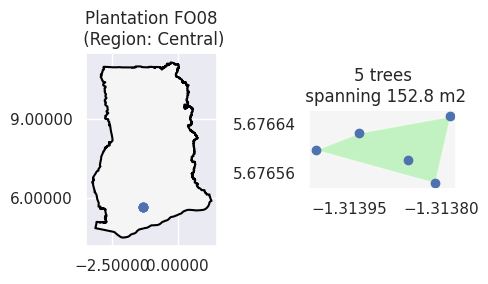

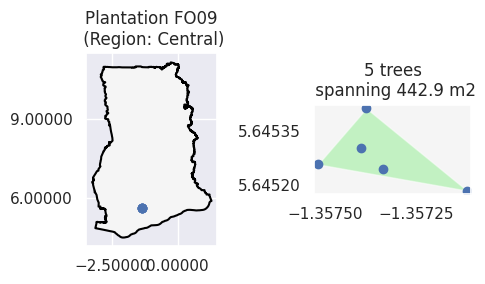

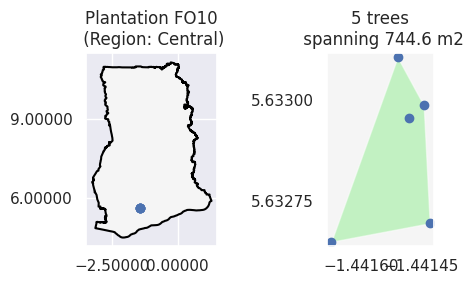

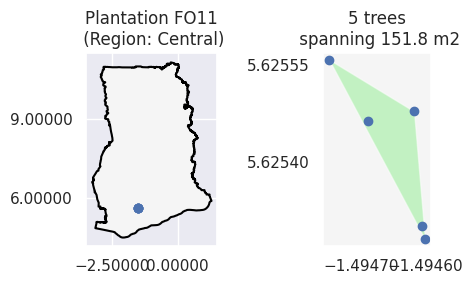

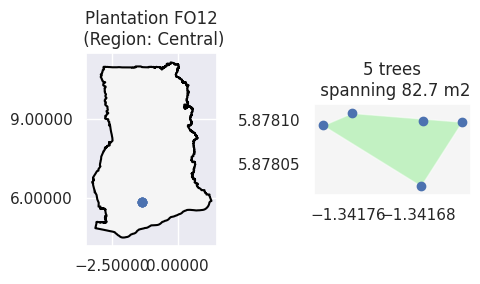

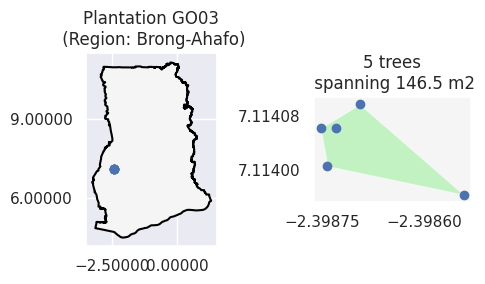

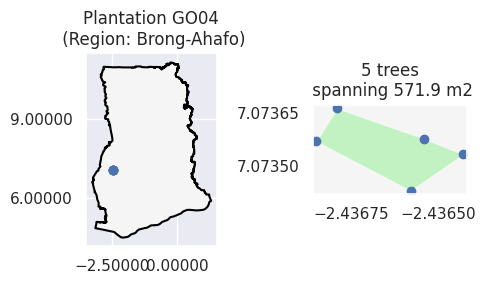

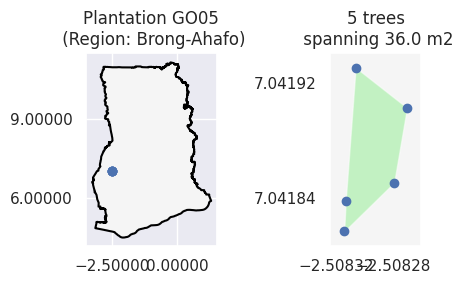

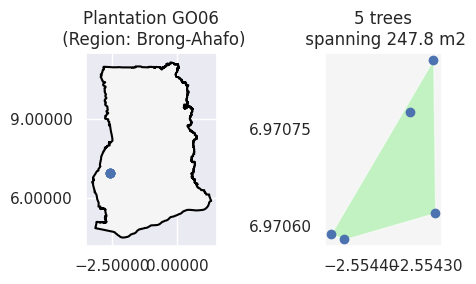

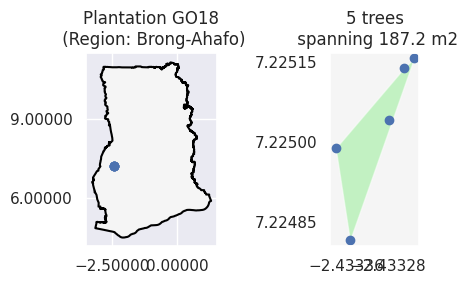

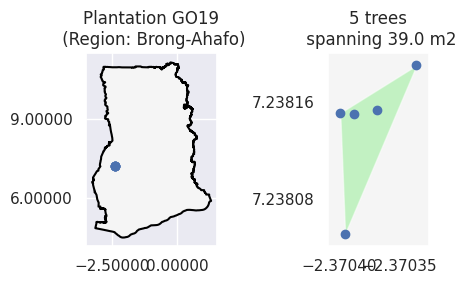

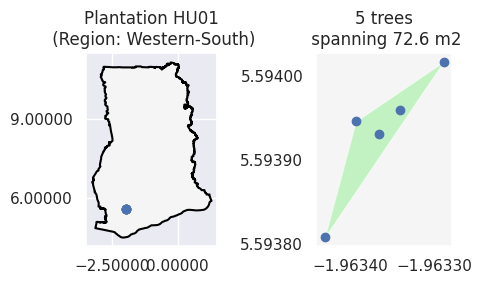

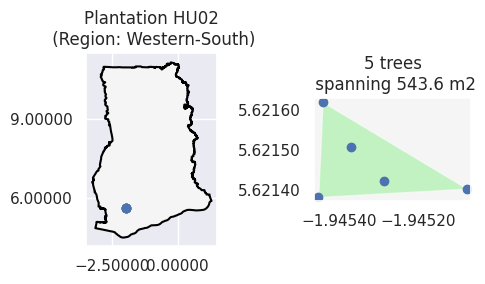

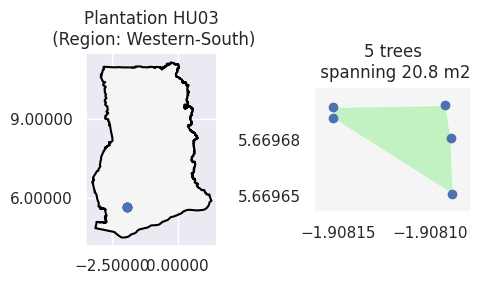

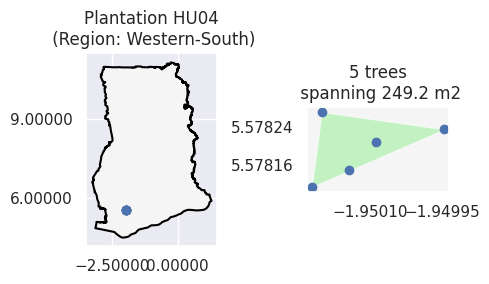

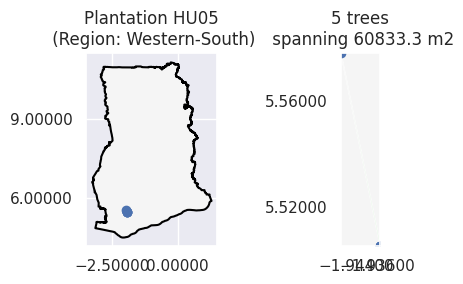

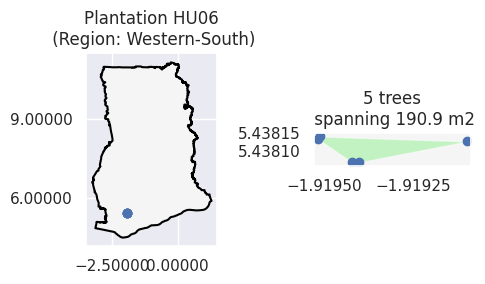

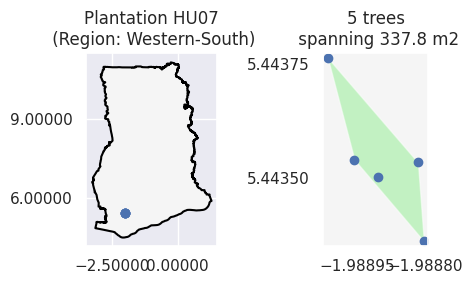

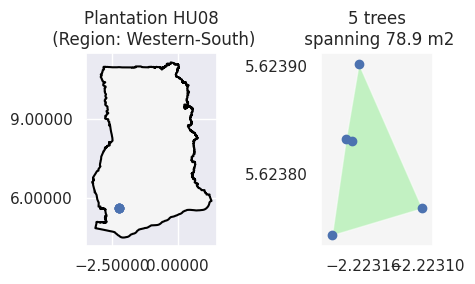

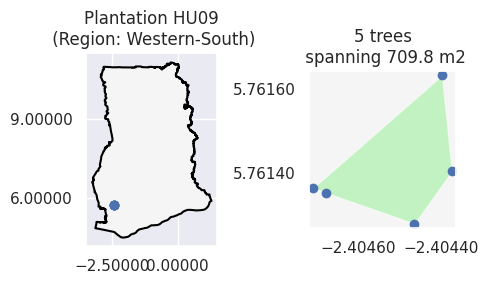

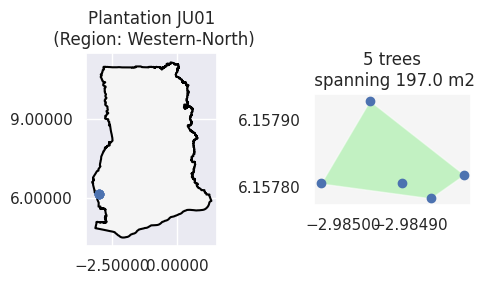

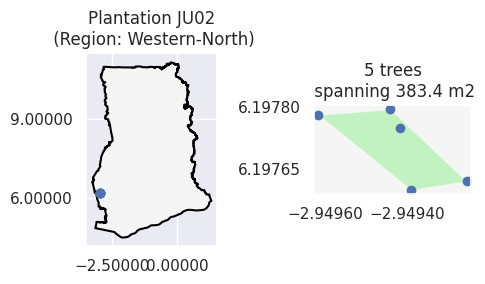

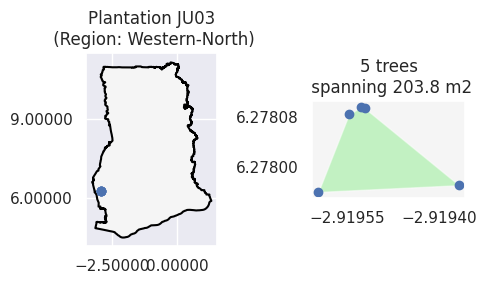

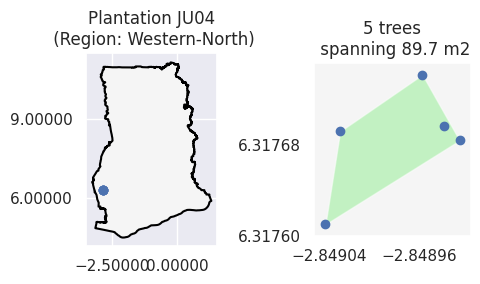

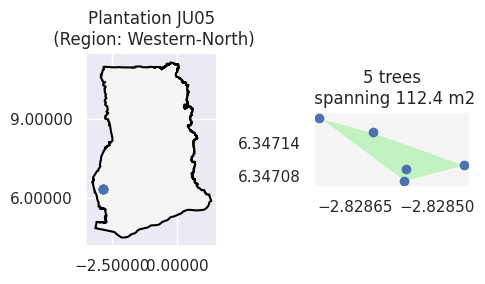

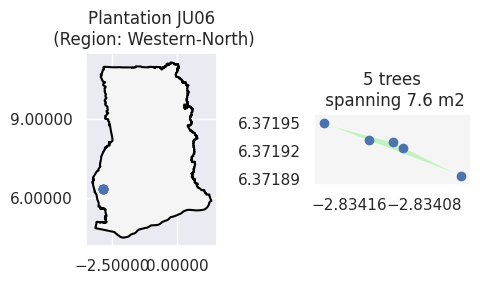

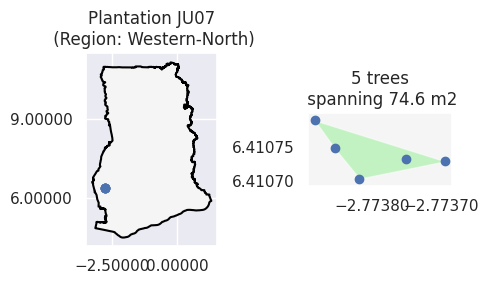

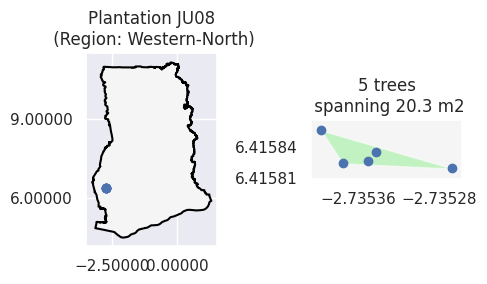

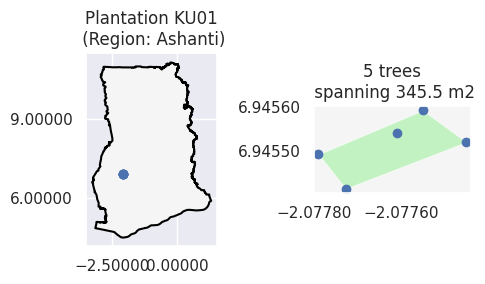

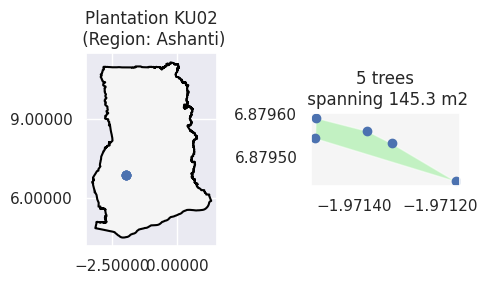

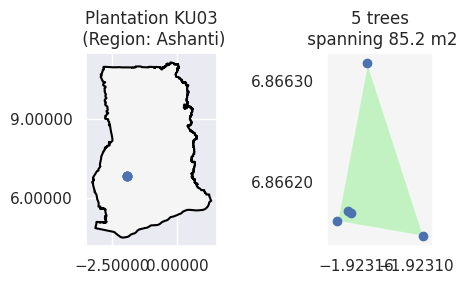

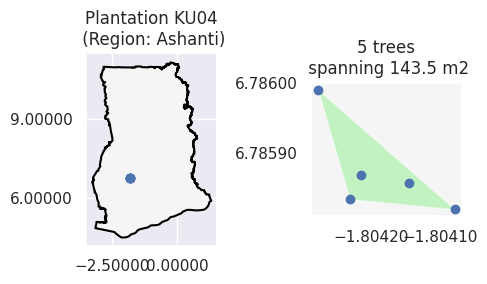

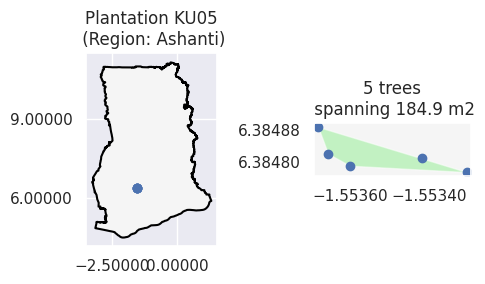

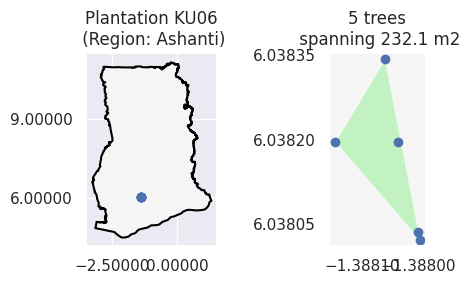

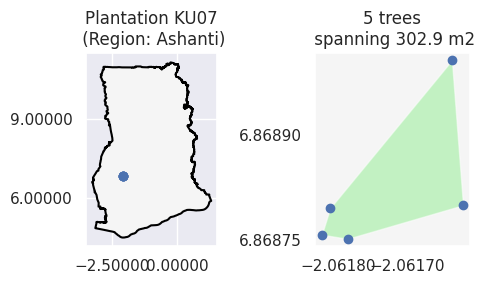

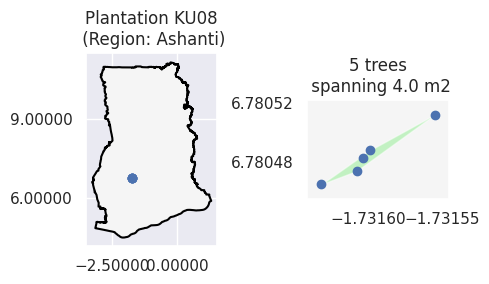

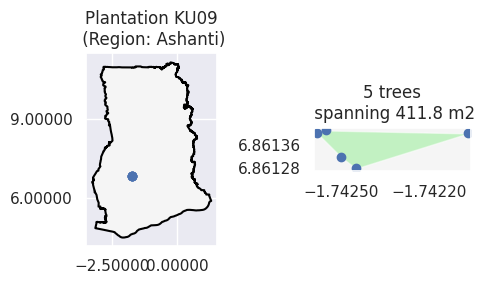

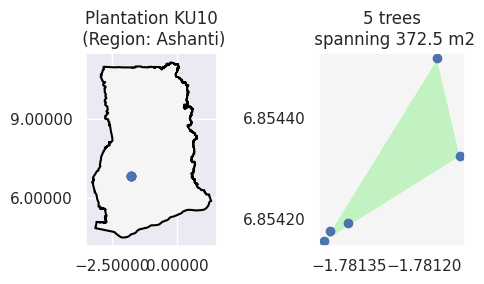

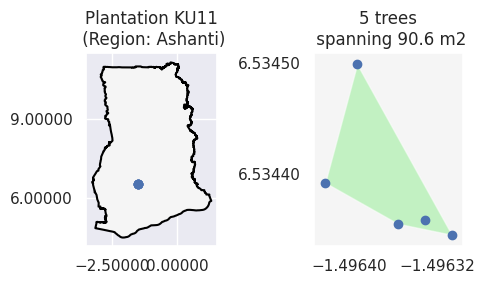

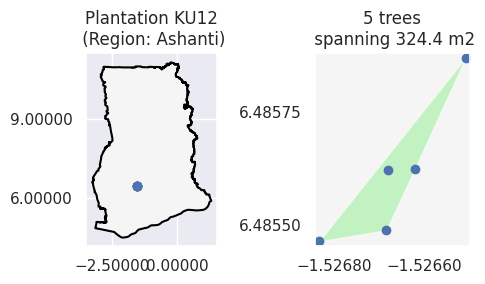

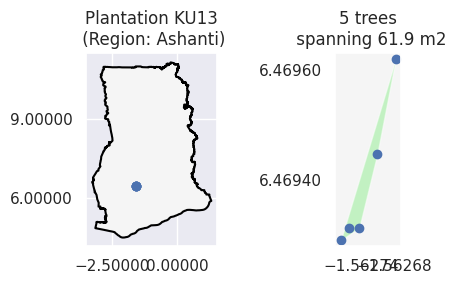

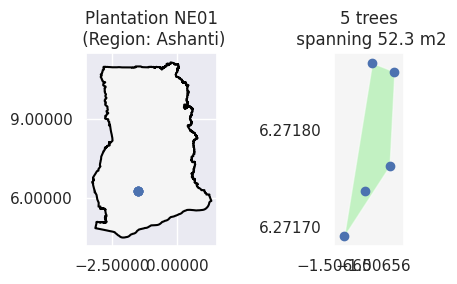

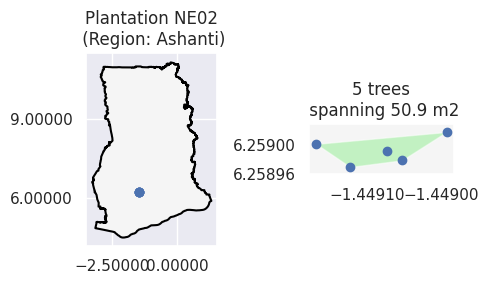

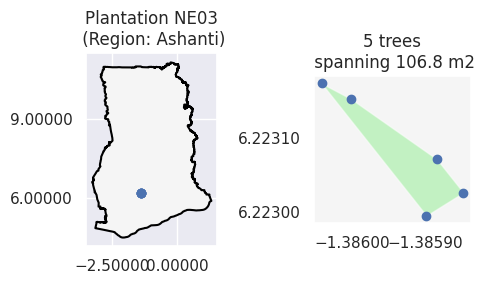

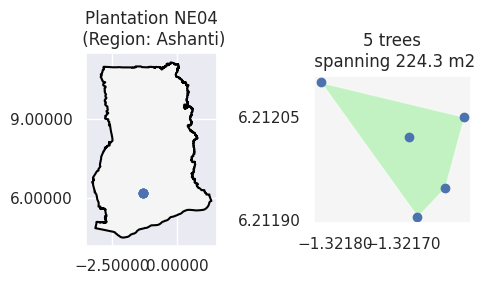

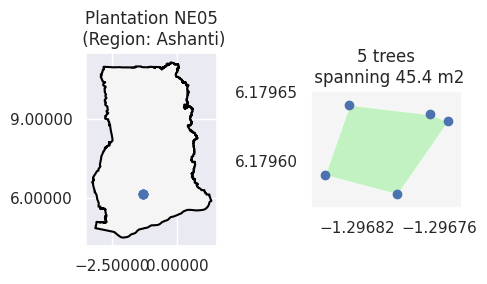

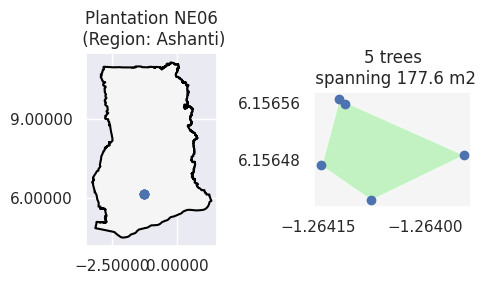

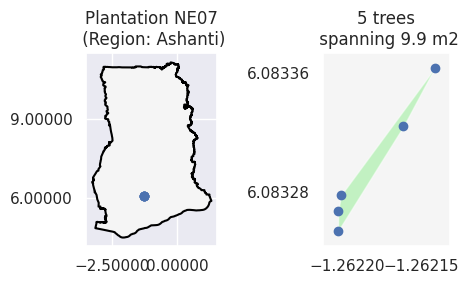

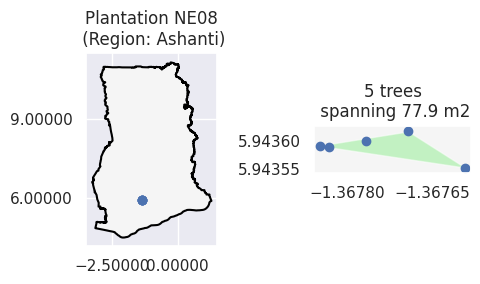

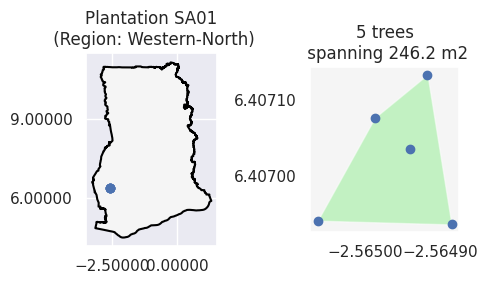

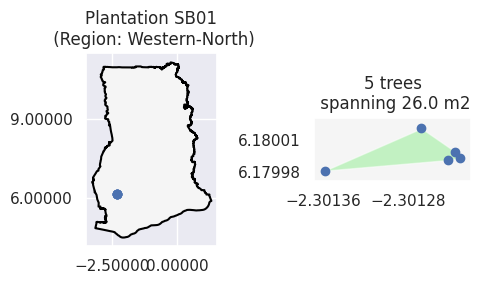

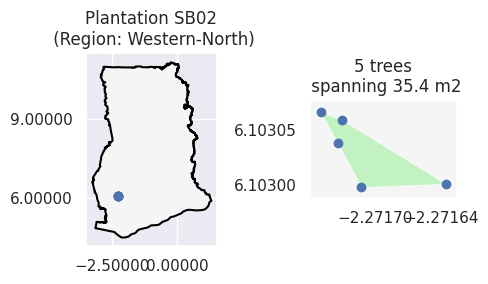

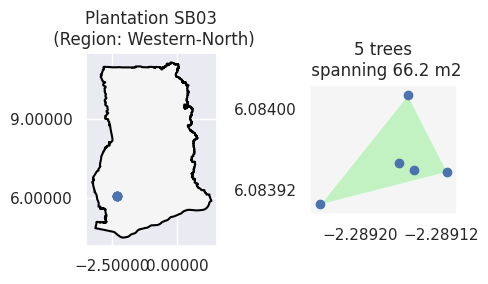

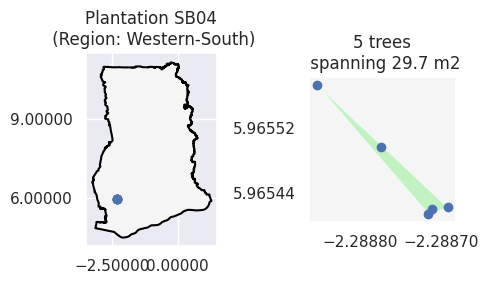

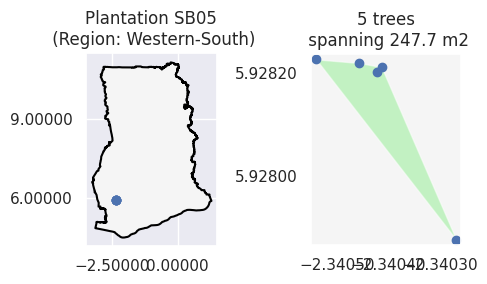

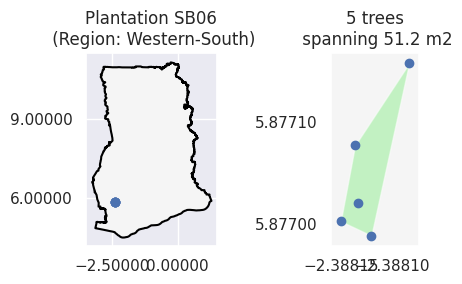

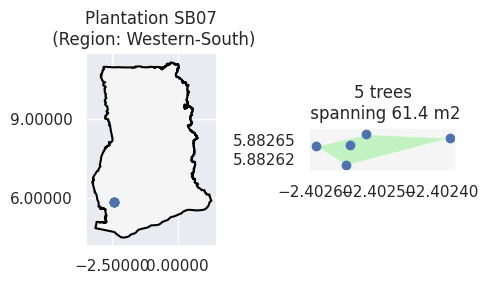

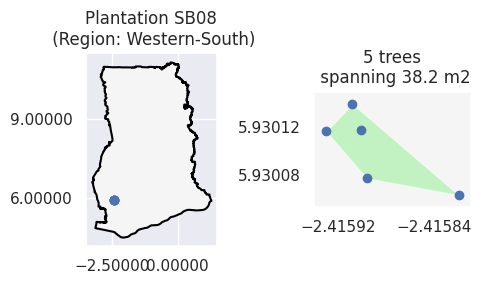

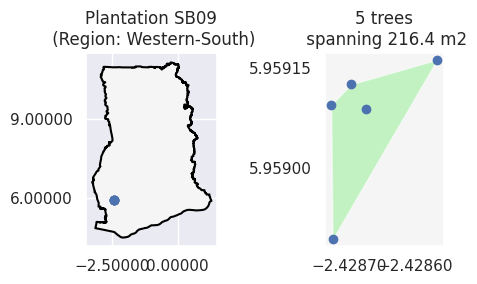

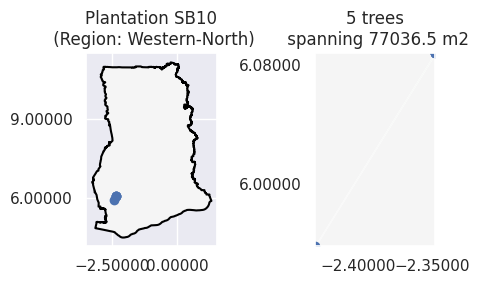

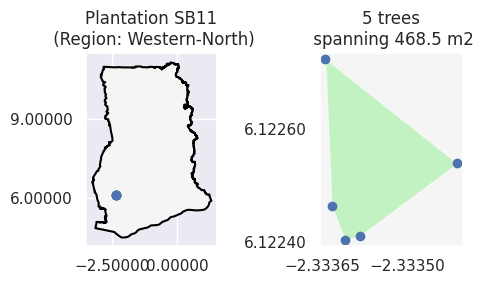

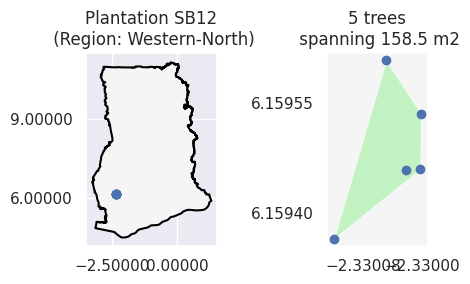

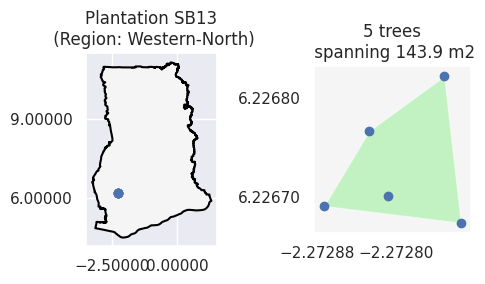

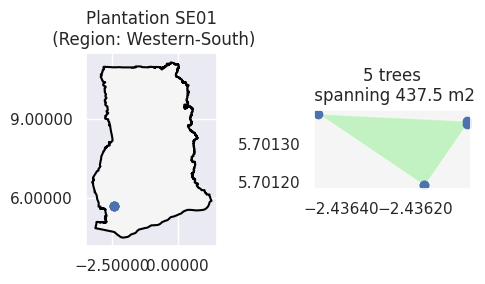

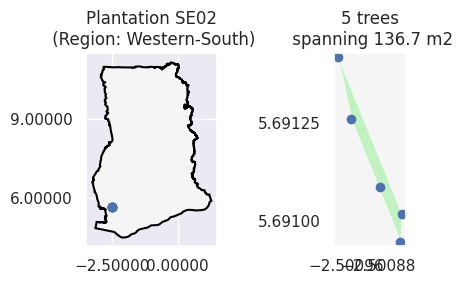

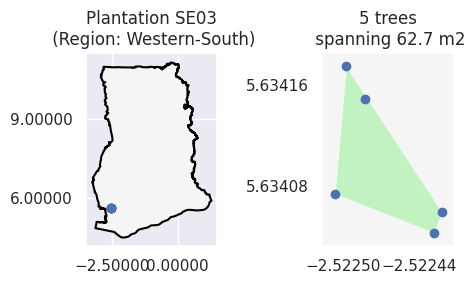

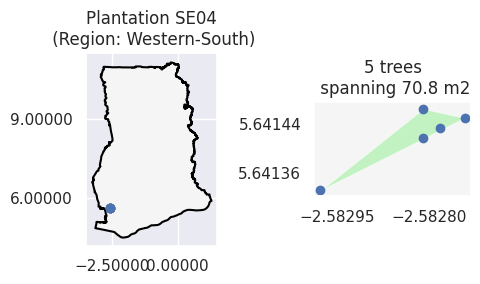

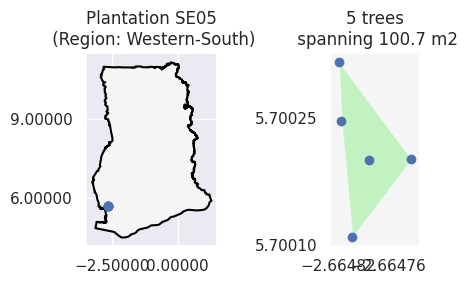

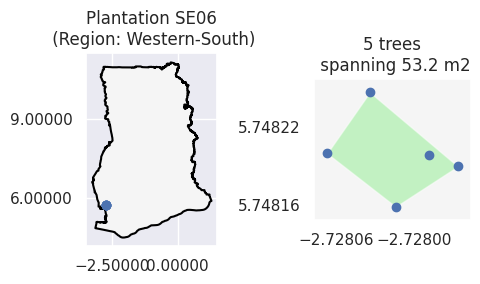

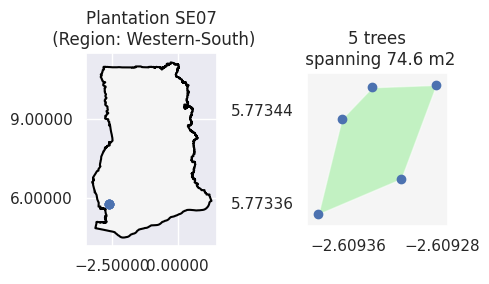

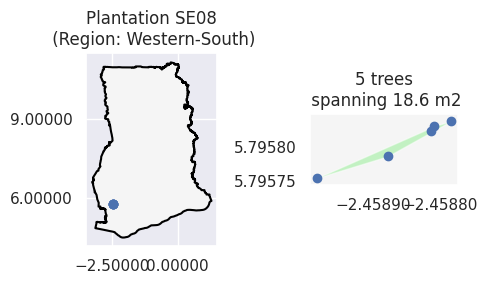

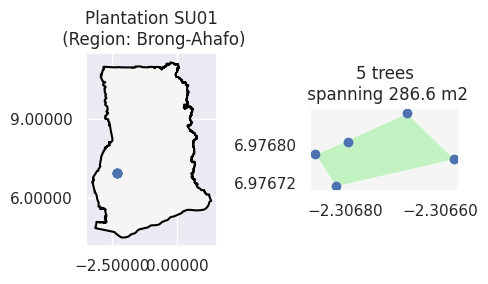

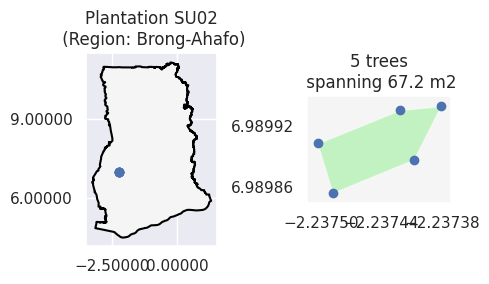

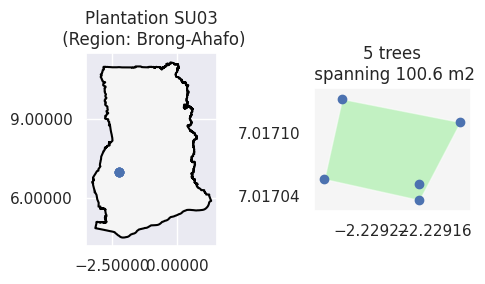

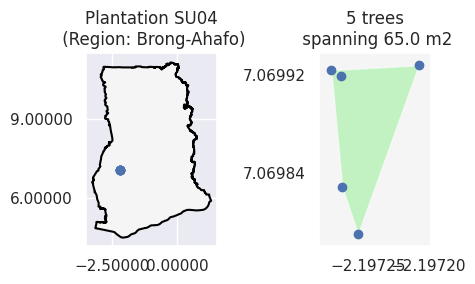

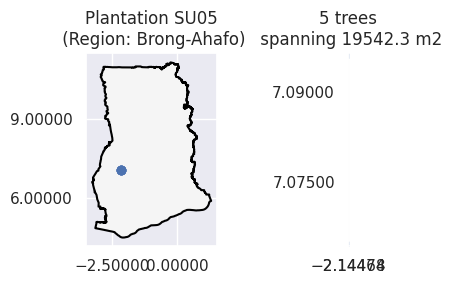

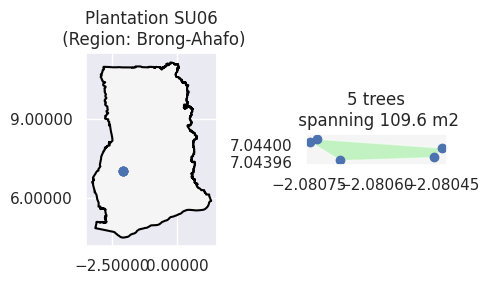

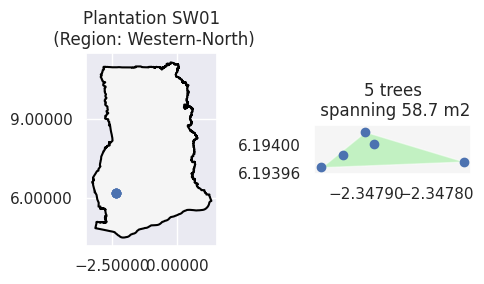

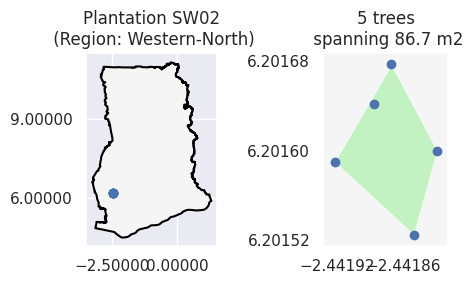

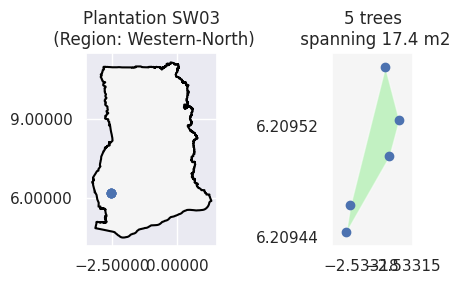

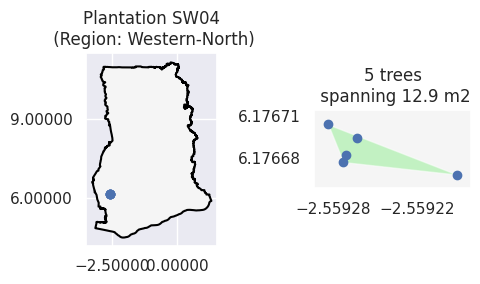

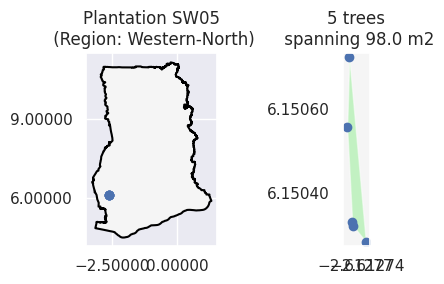

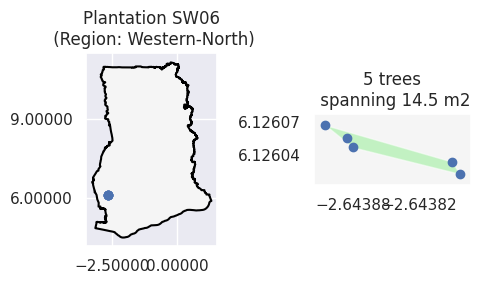

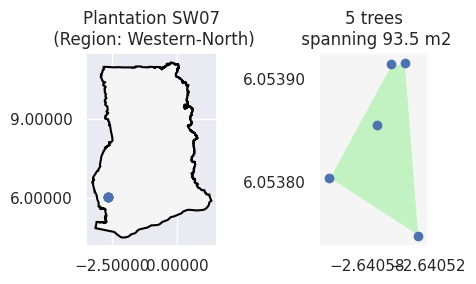

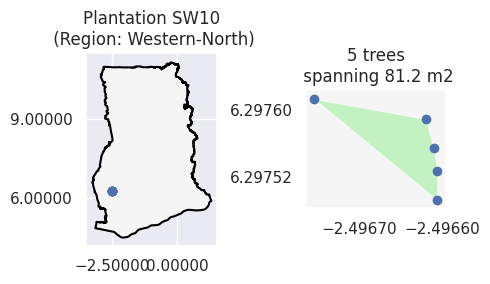

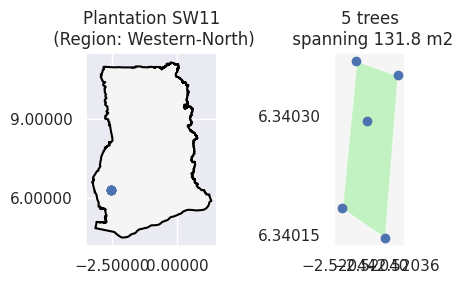

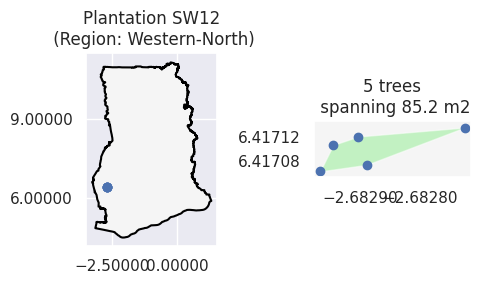

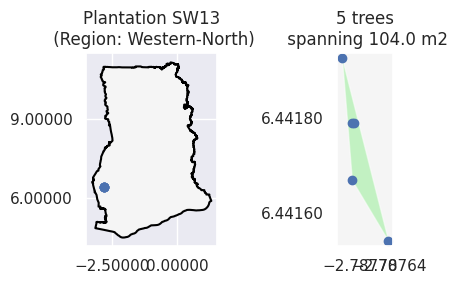

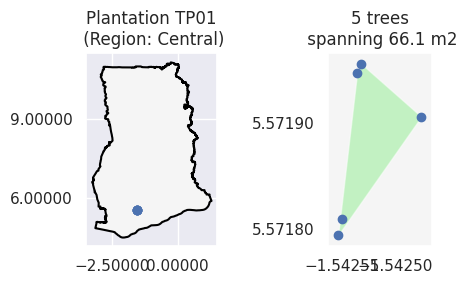

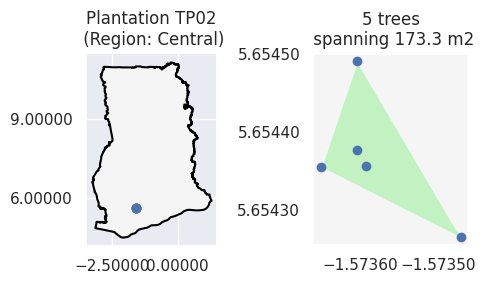

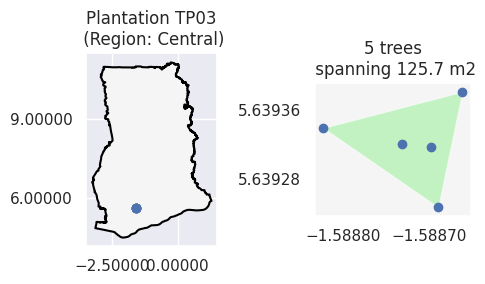

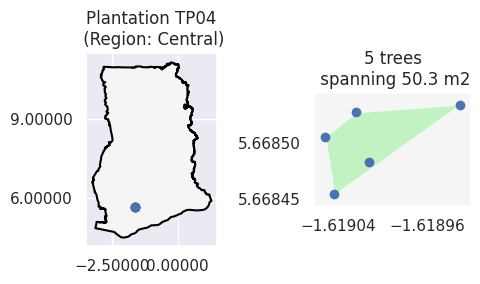

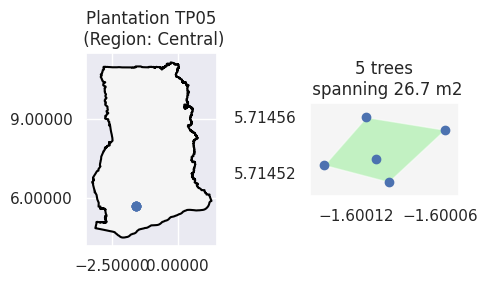

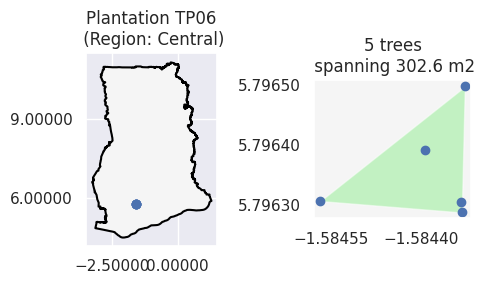

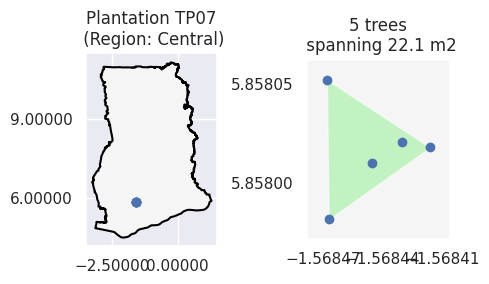

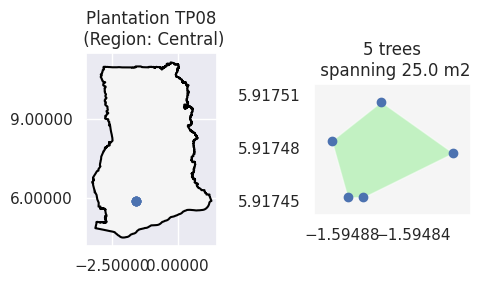

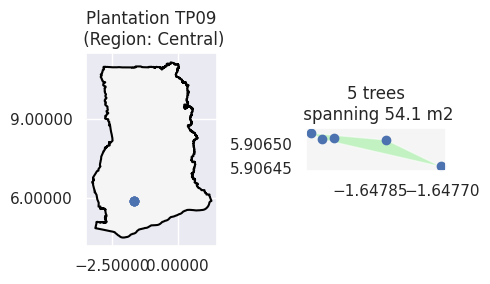

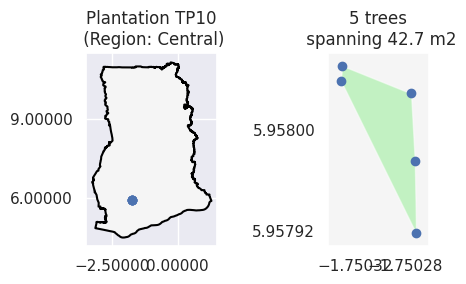

In [13]:
for s in sites:
    s.plot()

In [14]:
import joblib

joblib.dump(sites, SILVER_FOLDERPATH / "sites.pkl")

['/home/aga/Documents/clients/forestero/skymap/skymap/data/silver/sites.pkl']